In [1]:
# Install required libraries for data processing, ML, and visualization
!pip install ucimlrepo pandas numpy matplotlib scikit-learn

In [2]:
# Install imbalanced-learn for SMOTE (Synthetic Minority Over-sampling Technique)
!pip install imbalanced-learn

In [3]:
# Import essential libraries for data manipulation, numerical ops, visualization, and UCI datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [4]:
# ===== LOAD DATASET =====
# Fetch Taiwanese Bankruptcy Prediction dataset from UCI Repository (ID: 572)
dataset = fetch_ucirepo(id=572)

# Extract features and target
X = dataset.data.features.copy()
y = dataset.data.targets.copy()

# Convert target DataFrame to Series if needed
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# Combine features and target into single dataframe
df = X.copy()
df["Bankrupt?"] = y

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# ===== COMPREHENSIVE DATA EXPLORATION =====
# Dataset dimensions
print("Shape:", df.shape)

# Display sample records
print("\nFirst 5 rows:")
print(df.head())

# List all columns
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Class distribution
print("\nTarget distribution:")
print(df["Bankrupt?"].value_counts())

# Class distribution percentage
print("\nTarget distribution (%):")
print(df["Bankrupt?"].value_counts(normalize=True) * 100)

# Statistical summary
print("\nSummary statistics:")
print(df.describe())

# Check for infinite values
print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

# Non-numeric columns
print("\nNon-numeric columns:")
print(df.drop(columns=["Bankrupt?"]).select_dtypes(exclude=[np.number]).columns.tolist())

Shape: (6819, 96)

First 5 rows:
    ROA(C) before interest and depreciation before interest  \
0                                           0.370594          
1                                           0.464291          
2                                           0.426071          
3                                           0.399844          
4                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                           0.457733    
4                         

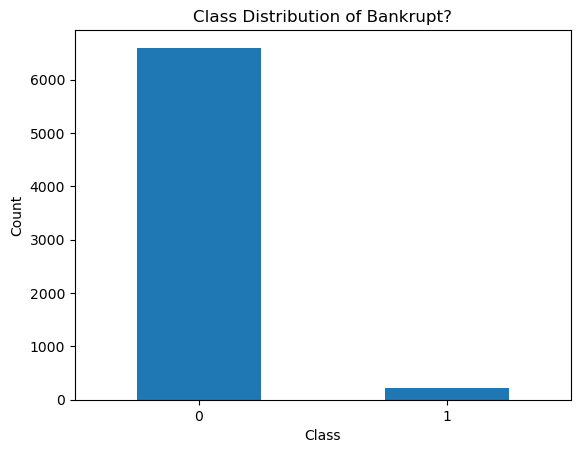

In [6]:
# ===== VISUALIZE CLASS DISTRIBUTION =====
# Plot histogram to visualize class imbalance
df["Bankrupt?"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Bankrupt?")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [7]:
# ===== DATA SPLITTING =====
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Separate features from target
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

# Split data: 80% training, 20% testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display split statistics
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (5455, 95)
X_test shape: (1364, 95)
y_train distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64
y_test distribution:
Bankrupt?
0    1320
1      44
Name: count, dtype: int64


In [8]:
# ===== CLASS IMBALANCE HANDLING WITH SMOTE =====
# Import SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
import pandas as pd

# Initialize SMOTE with random_state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE to training data - generates synthetic samples for minority class
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Compare class distributions before and after SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

After SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [9]:
# ===== RANDOM FOREST WITH SMOTE + CLASS WEIGHT =====
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with both SMOTE balancing AND class weights
# - SMOTE balances training data through oversampling
# - class_weight further penalizes minority class misclassifications
rf_smote_cw = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Apply class weight on top of SMOTE
)

# Train model on SMOTE-balanced data with class weights
rf_smote_cw.fit(X_train_smote, y_train_smote)

# Make predictions on test set
y_pred = rf_smote_cw.predict(X_test)

In [10]:
# Verify predictions have been generated
y_pred = rf_smote_cw.predict(X_test)
print("Predictions completed.")

Predictions completed.


In [11]:
# ===== MODEL EVALUATION METRICS =====
# Import comprehensive evaluation metrics
from sklearn.metrics import (
    accuracy_score,           # Overall correctness
    precision_score,          # TP / (TP + FP)
    recall_score,             # TP / (TP + FN)
    f1_score,                 # Harmonic mean of precision and recall
    balanced_accuracy_score,  # Average recall for each class
    classification_report,    # Detailed per-class metrics
    confusion_matrix,         # True/false positives and negatives
    ConfusionMatrixDisplay    # Visualization of confusion matrix
)

# Compute training and testing accuracy (model trained on SMOTE-resampled data)
y_train_pred = rf_smote_cw.predict(X_train_smote)
print("Training Accuracy:", accuracy_score(y_train_smote, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

# Calculate and display key metrics on test set
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training Accuracy: 1.0
Testing Accuracy: 0.9611436950146628
Precision: 0.9681226214735307
Recall: 0.9611436950146628
F1-score: 0.9641632890658263
Balanced Accuracy: 0.7821969696969697

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.43      0.59      0.50        44

    accuracy                           0.96      1364
   macro avg       0.71      0.78      0.74      1364
weighted avg       0.97      0.96      0.96      1364



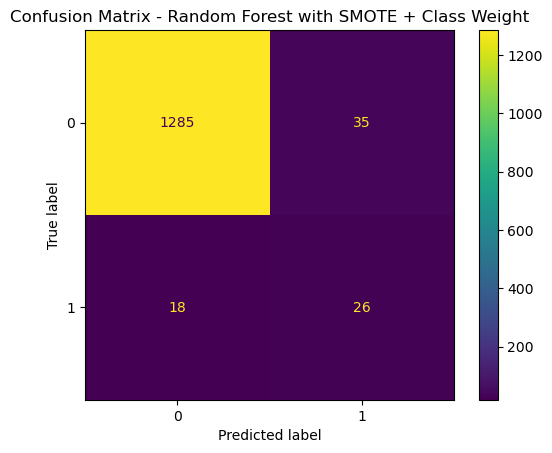

In [12]:
# ===== CONFUSION MATRIX VISUALIZATION =====
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest with SMOTE + Class Weight")
plt.show()

In [13]:
# ===== FEATURE IMPORTANCE ANALYSIS =====
# Extract feature importances and create ranked dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,                          # Feature names
    "Importance": rf_smote_cw.feature_importances_ # Importance scores
}).sort_values(by="Importance", ascending=False)

# Display top 15 most important features
print(feature_importance.head(15))

                                              Feature  Importance
9                Continuous interest rate (after tax)    0.058452
35                         Total debt/Total net worth    0.058276
18            Persistent EPS in the Last Four Seasons    0.050704
7                         After-tax net Interest Rate    0.049656
85                         Net Income to Total Assets    0.047730
67                  Retained Earnings to Total Assets    0.045263
39                               Borrowing dependency    0.041861
37                                   Net worth/Assets    0.029136
36                                       Debt ratio %    0.027604
89                 Net Income to Stockholder's Equity    0.026424
42              Net profit before tax/Paid-in capital    0.026243
90                                Liability to Equity    0.025259
6                           Pre-tax net Interest Rate    0.022314
2    ROA(B) before interest and depreciation after...    0.020753
22        

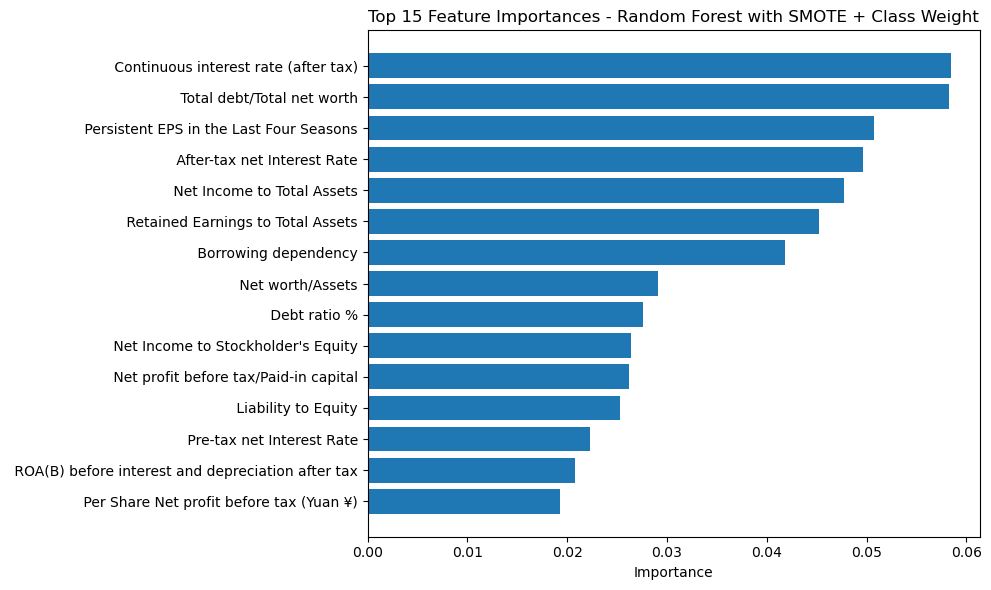

In [14]:
# ===== FEATURE IMPORTANCE VISUALIZATION =====
# Get top 15 features sorted for visualization
top15 = feature_importance.head(15).sort_values(by="Importance")

# Create horizontal bar chart of feature importances
plt.figure(figsize=(10, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest with SMOTE + Class Weight")
plt.tight_layout()
plt.show()